# Exploratory Data Analysis: Social Media Sentiment
**Task:** EDA, Basic Statistics, and Data Summary.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from datasets import load_dataset
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from collections import Counter
import re
import string

# Set plot style
sns.set_theme(style="whitegrid")

### Loading Data & Summary

In [10]:
# Download the TweetEval dataset
print("Downloading dataset from HuggingFace")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Convert the 'train' split into a Pandas DataFrame
df_train = pd.DataFrame(dataset['train'])

# Display structural information about the dataset
print("\nDataset Summary:")
print(df_train.info())

# Preview the raw data
# 'label' column: 0 = Negative, 1 = Neutral, 2 = Positive
print("\nRaw Data Preview (First 5 Rows):")
display(df_train.head())

# Check for missing values
print("\nMissing Values Check:")
print(df_train.isnull().sum())

# Analyze Class Distribution
print("\nClass Distribution (Frequency):")
class_counts = df_train['label'].value_counts().sort_index()
print(class_counts)

print("\nClass Distribution (Percentage):")
print(df_train['label'].value_counts(normalize=True).sort_index() * 100)


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    45615 non-null  object
 1   label   45615 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 712.9+ KB
None

Raw Data Preview (First 5 Rows):


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2



Missing Values Check:
text     0
label    0
dtype: int64

Class Distribution (Frequency):
label
0     7093
1    20673
2    17849
Name: count, dtype: int64

Class Distribution (Percentage):
label
0    15.549710
1    45.320618
2    39.129672
Name: proportion, dtype: float64


1. Data Integrity

The dataset consists of 45,615 entries with two primary columns: text (the raw tweet content) and label (the target sentiment). There are no missing values (nulls) in either column, ensuring the dataset is complete and ready for preprocessing.

2. Class Distribution and Imbalance

Analyzing the class proportions reveals a clear imbalance in the data:

- Neutral (1): 45.3%
- Positive (2): 39.1%
- Negative (0): 15.6%

The dataset is heavily dominated by Neutral and Positive tweets, while Negative sentiment represents only about 1/6th of the total data.

3. Preliminary Data Audit

A quick look at the raw text shows common Twitter-specific elements:

- Handle mentions: (e.g., @user)
- Metadata/Re-tweets: (e.g., QT @user)
- Punctuation and contractions: (e.g., Headley's, bout)

### Tweet Length Analysis

Word Count Statistics per Sentiment Class:


,Count,Mean,Std Dev,Min,25% (Q1),50% (Median),75% (Q3),Max
label,,,,,,,,
0,7093.0,20.218525,4.757001,4.0,17.0,21.0,24.0,35.0
1,20673.0,18.979732,4.924530,1.0,16.0,19.0,23.0,33.0
2,17849.0,19.146059,4.971840,4.0,16.0,19.0,23.0,34.0


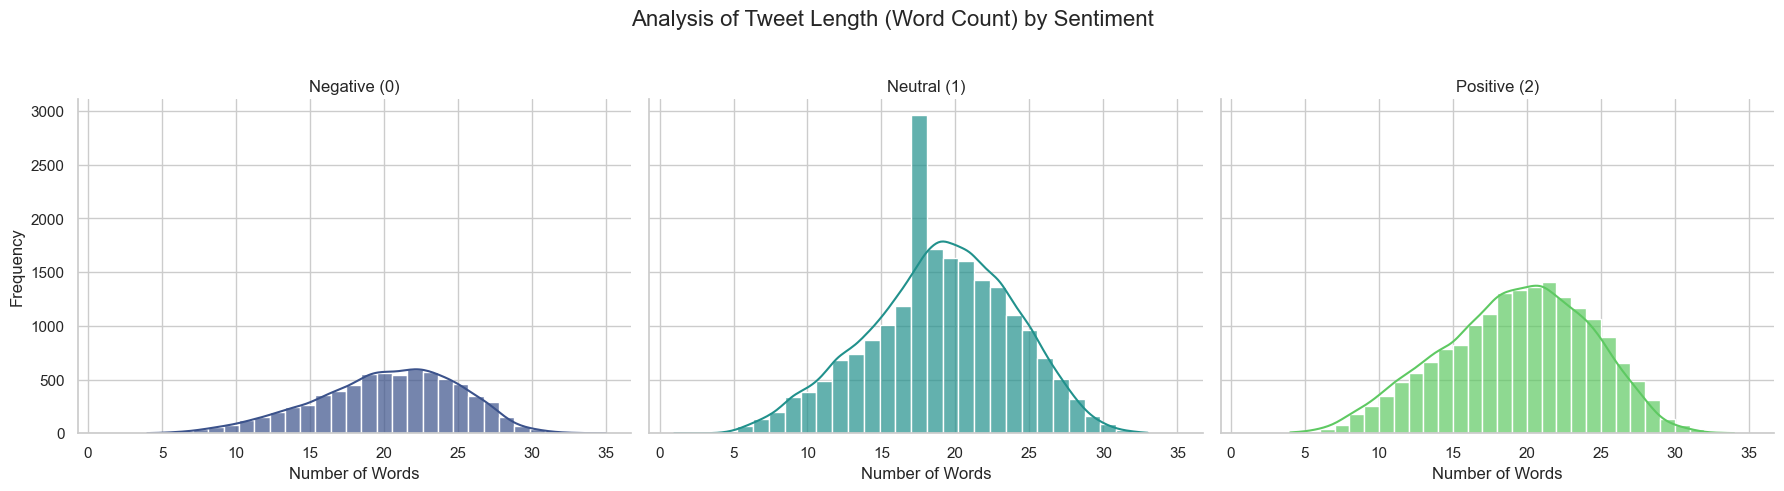

In [14]:
# Calculate word counts
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

# Detailed descriptive statistics for Word Count grouped by Sentiment
print("Word Count Statistics per Sentiment Class:")
stats = df_train.groupby('label')['word_count'].describe(percentiles=[.25, .5, .75])
stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25% (Q1)', '50% (Median)', '75% (Q3)', 'Max']
display(stats)

# Create the visualization
g = sns.FacetGrid(df_train, col="label", hue="label", palette='viridis', height=5, aspect=1.2)
g.map(sns.histplot, "word_count", kde=True, bins=30, alpha=0.7)
g.set_axis_labels("Number of Words", "Frequency")
g.set_titles(col_template="Sentiment: {col_name}")

axes = g.axes.flatten()
axes[0].set_title("Negative (0)")
axes[1].set_title("Neutral (1)")
axes[2].set_title("Positive (2)")

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Analysis of Tweet Length (Word Count) by Sentiment', fontsize=16)

plt.show()

1. Uniformity Across Classes

The Mean and Median word counts are remarkably similar across all three sentiments, hovering between 19 and 20 words. This suggests that sentiment does not significantly dictate the length of a tweet in this dataset.

2. Neutral Class Peak

The histogram for the Neutral (1) class shows a sharp spike around the 18-word mark. This could indicate a large number of automated tweets, news headlines, or status updates that follow a standardized template.

3. Data Range 

The word counts range from as low as 1 word to a maximum of 35 words. The Standard Deviation (~4.8) is low, confirming that most tweets stay within a tight range (roughly 14 to 25 words).

### Word Clouds per Class


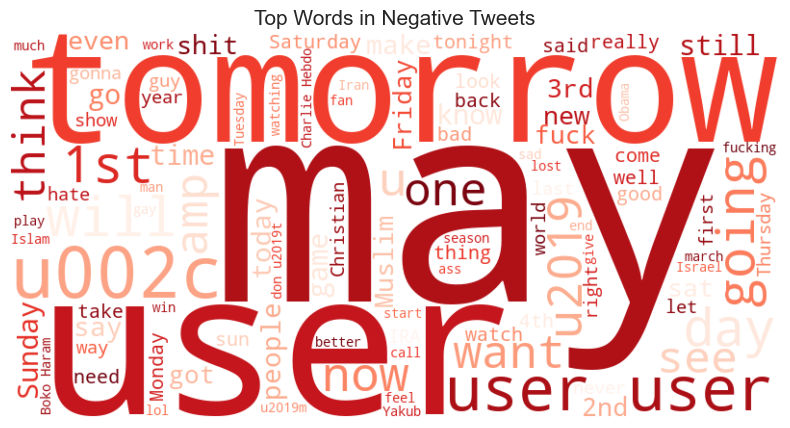

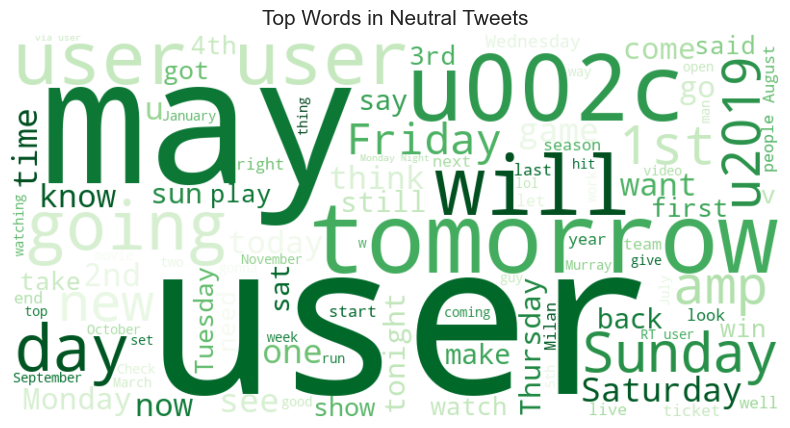

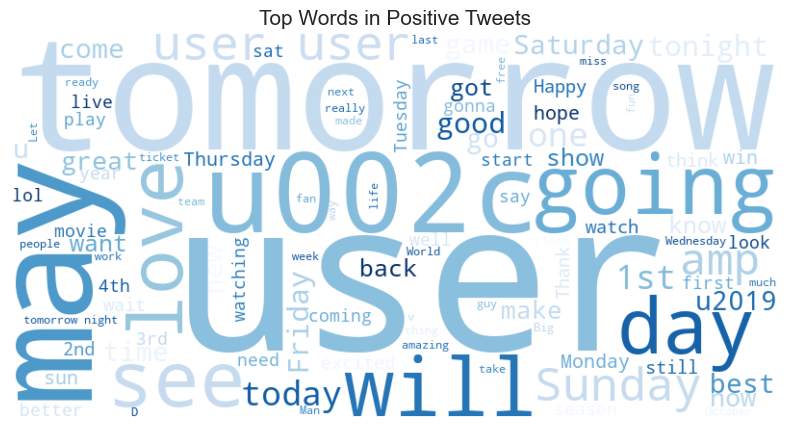

In [15]:
def plot_wordcloud(label_id, title, color):
    text = " ".join(t for t in df_train[df_train['label']==label_id].text)
    wordcloud = WordCloud(background_color='white', max_words=100, width=800, height=400, colormap=color).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.show()

# Run for each class
plot_wordcloud(0, 'Top Words in Negative Tweets', 'Reds')
plot_wordcloud(1, 'Top Words in Neutral Tweets', 'Greens')
plot_wordcloud(2, 'Top Words in Positive Tweets', 'Blues')

The Word Clouds provide a visual representation of the most frequent terms in each sentiment class. However, they also reveal the high level of "noise" present in social media data:

1. Dominance of Neutral Terms

Across all three categories, neutral words like "user", "tomorrow", "will", and "day" are the most prominent. This indicates that a large portion of the tweets consists of daily updates, scheduling, or factual statements rather than purely emotional expressions.

2. Class-Specific Patterns

Negative Tweets (Red): While "user" dominates, we can see high-intensity negative terms like "sad", "fuck", "hate", and "bad" emerging. This confirms that the negative labels are often associated with strong language or frustration.

Neutral Tweets (Green): This cloud is heavily populated with time-related words ("Friday", "Sunday", "May", "1st"). This supports our earlier theory that neutral tweets are often news-like or event-related.

Positive Tweets (Blue): We clearly see positive "anchor words" such as "love", "good", "best", "great", and "hope".

3. The "User" Problem

The overwhelming presence of the word "user" (a placeholder for mentions) suggests that further text cleaning (removal of high-frequency stop words or placeholders) might be beneficial before feeding the data into a Machine Learning model, as it currently masks more subtle emotional cues.

The overlap of common words across all classes explains why simple word-counting methods might struggle. The sentiment is often hidden in the context surrounding these common words, not just the words themselves.

### Top N-Grams

In [20]:
def light_clean(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove "user" placeholder
    text = text.replace('user', '')
    # 3. Remove HTML entities like &amp; and unicode leftovers like u002c
    text = re.sub(r'&\w+;', '', text)
    text = re.sub(r'u[0-9a-fA-F]{4}', '', text)
    # 4. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 5. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 6. Remove extra whitespaces
    text = " ".join(text.split())
    return text

# Apply the cleaning
print("Cleaning text for better EDA...")
df_train['clean_text'] = df_train['text'].apply(light_clean)

# Preview the difference
display(df_train[['text', 'clean_text']].head())

Cleaning text for better EDA...


,text,clean_text
0,"""QT @user In the original draft of the 7th boo...",qt in the original draft of the 7th book remus...
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains out of the ...
2,Sorry bout the stream last night I crashed out...,sorry bout the stream last night i crashed out...
3,Chase Headley's RBI double in the 8th inning o...,chase headleys rbi double in the 8th inning of...
4,@user Alciato: Bee will invest 150 million in ...,alciato bee will invest 150 million in january...


C:\Users\User\AppData\Local\Temp\ipykernel_27836\1483406213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='Reds_r')


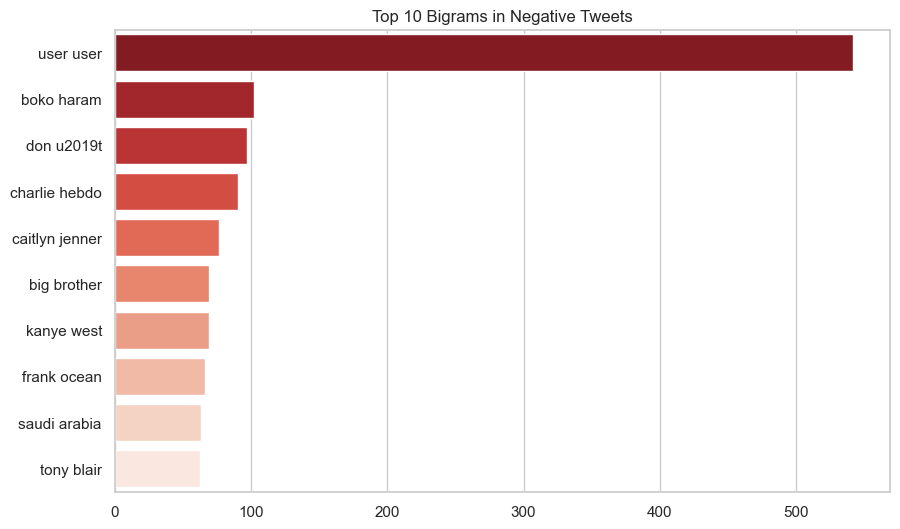

C:\Users\User\AppData\Local\Temp\ipykernel_27836\1483406213.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='Greens_r')


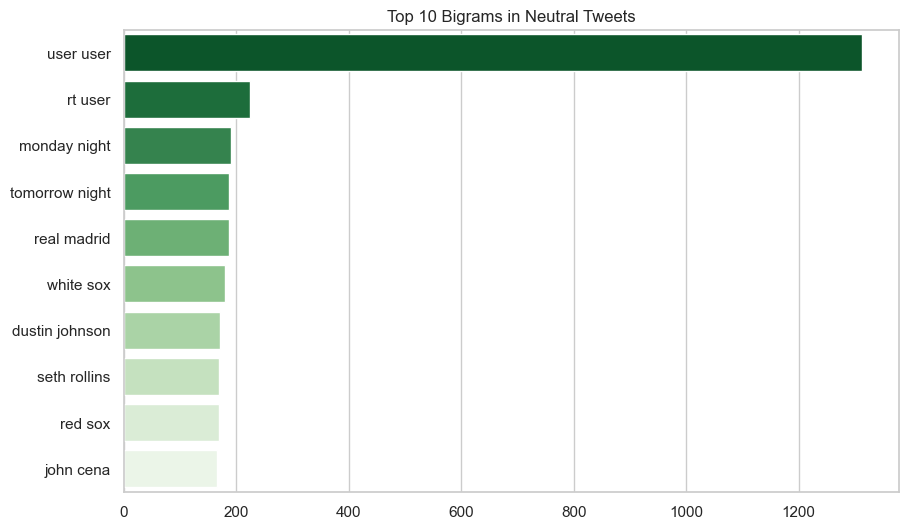

C:\Users\User\AppData\Local\Temp\ipykernel_27836\1483406213.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='Blues_r')


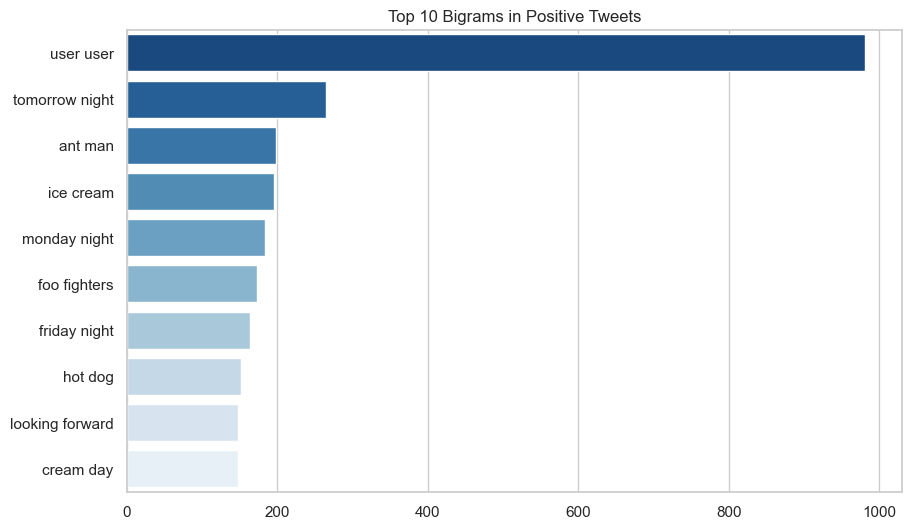

In [21]:
def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Plotting Top Bigrams for Negative Sentiment
top_bigrams = get_top_bigrams(df_train[df_train['label']==0]['text'])
x, y = map(list, zip(*top_bigrams))
plt.figure(figsize=(10,6))
sns.barplot(x=y, y=x, palette='Reds_r')
plt.title('Top 10 Bigrams in Negative Tweets')
plt.show()

# Plotting Top Bigrams for Neutral Sentiment
top_bigrams = get_top_bigrams(df_train[df_train['label']==1]['text'])
x, y = map(list, zip(*top_bigrams))
plt.figure(figsize=(10,6))
sns.barplot(x=y, y=x, palette='Greens_r')
plt.title('Top 10 Bigrams in Neutral Tweets')
plt.show()

# Plotting Top Bigrams for Positive Sentiment
top_bigrams = get_top_bigrams(df_train[df_train['label']==2]['text'])
x, y = map(list, zip(*top_bigrams))
plt.figure(figsize=(10,6))
sns.barplot(x=y, y=x, palette='Blues_r')
plt.title('Top 10 Bigrams in Positive Tweets')
plt.show()

The bigrams reveal a fascinating aspect of the TweetEval dataset: sentiment is often context-dependent rather than just adjective-based.

1. Negative Bias in Events

The prevalence of terms like "Boko Haram" and "Charlie Hebdo" suggests that the Negative label is frequently assigned to tweets discussing tragic world events or controversial public figures ("Kanye West", "Tony Blair"). This indicates that the model must learn the association between specific topics and sentiment.

2. Neutrality as Schedulin
The Neutral class is dominated by temporal bigrams like "Monday night" and "tomorrow night", confirming that factual or scheduling tweets are the backbone of this category.

3. Positive Associations

Positive tweets show a mix of anticipation ("looking forward") and everyday pleasures ("ice cream", "hot dog").

4. The "User User" Problem

Despite cleaning, the repetition of "user user" remains the top bigram across all classes. This is due to tweets containing multiple mentions. This further reinforces the need for advanced models that can ignore these repetitive placeholders and focus on the surrounding context.